### Section 2.3, écoulement d'un film de fluide Newtonien dans une conduite

|<img src="images/usherb_transp.gif"> |Pierre Proulx, ing, professeur|
|:---|:---|
|Département de génie chimique et de génie biotechnologique |** GCH200-Phénomènes d'échanges I **|

>  Le développement fait dans Transport Phenomena sera encore répété mais nous n'irons pas ici autant dans le détail que dans la section 2.2, Remarquez bien comment la courbure de la géométrie (coordonnées cylindriques) a un effet sur le bilan. <img src='images/Chap-2-Section-2-3.png' width=50% height=50%>
>Vous pouvez suivre le développement détaillé à l'aide du livre et voir comment les équations de bilans initiales deviennent les profils de vitesse, de force, débit, etc...

In [1]:
#
# Préparation de l'affichage et des outils de calcul symbolique
#
import sympy as sp          
from IPython.display import *
sp.init_printing(use_latex=True)
%matplotlib inline

In [2]:
# Paramètres, variables et fonctions
#
r,delta_r,L,rho,g,mu,R,P_0,P_L=sp.symbols('r,delta_r,L,rho,g,mu,R,P_0,P_L')
C1=sp.symbols('C1')
phi_rz=sp.Function('phi_rz')
phi_zz=sp.Function('phi_zz')

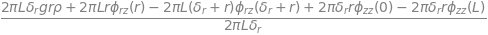

In [3]:
#
# Équation du bilan des forces
#
eq=2*sp.pi*r*L*phi_rz(r)      -2*sp.pi*(r+delta_r)*L*phi_rz(r+delta_r)
eq=eq+2*sp.pi*delta_r*r*phi_zz(0)-2*sp.pi*r*delta_r*phi_zz(L)
eq=eq+2*sp.pi*r*delta_r*L*rho*g
#eq=r*phi_rz(r)/delta_r-(r+delta_r)*phi_rz(r+delta_r)/delta_r+r*P_0/L-r*P_L/L 
#
# pose de la limite quand dr tends vers 0
#
eq=eq/(2*sp.pi*L*delta_r)
display(eq)

In [4]:
eq1=sp.limit(eq,delta_r,0).doit()
display(eq1)

In [5]:
eq1=eq1.subs(phi_zz(0),P_0)     # les termes de convection s'annulent comme en 2.2
eq1=eq1.subs(phi_zz(L),P_L)     # mais il reste le terme de pression
display(eq1)

In [6]:
# Loi de Newton, le terme phi ne contient que le cisaillement, pas de vitesse radiale.
tau=sp.Function('tau_rz')
eq2=sp.Eq(eq1.subs(phi_rz(r),tau(r)),0)
display(eq2)

In [7]:
eq2=sp.dsolve(eq2)
display(eq2)

In [8]:
vz=sp.Function('v_z')(r)
newton=-mu*sp.Derivative(vz,r)
eq3=eq2.subs(tau(r),newton)
eq3=eq3.subs(C1,0)               # C1 doit être nulle sinon on a une force infinie en r=0
display(eq3)

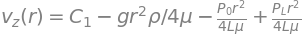

In [9]:
eq4=sp.dsolve(eq3,vz)      # rhs pour avoir la droite de l'équation vz=...
display(eq4)

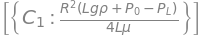

In [10]:
constante=sp.solve(sp.Eq(eq4.rhs.subs(r,R),0),'C1',dict=True)   # Condition de non-glissement à la paroi
display(constante)
constante=constante[0]     

vitesse en fonction de r


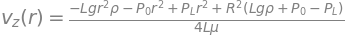

In [11]:
vz=eq4.subs(constante)
print('vitesse en fonction de r')
display(vz.simplify())

Force


'évalué en r=R devient'

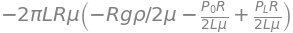

In [12]:
print('Force')
#
# collect et simplify simplifient l'expression, c'est purement cosmétique.
#
display(-mu*vz.lhs.diff(r)*2*sp.pi*r*L)
display('évalué en r=R devient')
display(-mu*vz.rhs.diff(r).subs(r,R)*2*sp.pi*R*L)

débit et vitesse moyenne


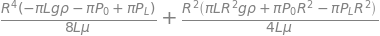

In [13]:
print( 'débit et vitesse moyenne')
vz=vz.rhs # On enlève le terme de gauche et à partir d'ici on travaille seulement avec la partie droite
debit=sp.integrate(2*sp.pi*vz*r,(r,0,R))
display(debit)

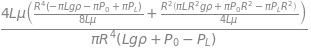

In [14]:
vmax=vz.subs(r,0)
display(debit/(sp.pi*R**2)/vmax)   # ce calcul donne quoi?

Reynolds=  1350


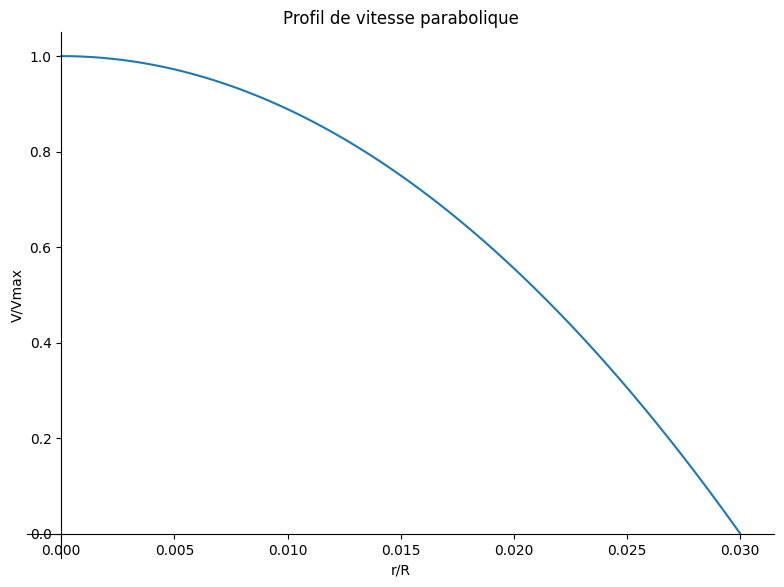

In [15]:
# Maintenant traçons le profil en donnant des valeurs de paramètres réalistes
#
dico={'rho':1000, 'mu':0.001, 'R':0.03, 'L':100,'P_0':10,'P_L':0,'g':0}  # g=0, horizontal
vzg=vz.subs(dico)
vzmax=vzg.subs(r,0)
display(vzg,vzmax)
print('Reynolds= {:5.0f}'.format(vzmax*R.subs(dico)*2*rho.subs(dico)/mu.subs(dico)))
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize']=8,6
sp.plot(vzg.subs(dico)/vzmax,(r,0,R.subs(dico)),title='Profil de vitesse parabolique',
       ylabel='V/Vmax',xlabel='r/R');

### À partir du profil de vitesses on peut calculer:

* La force que le fluide exerce sur la conduite: 

$
\begin{equation*}
  \boxed{ F = \int\limits_0 ^{2\pi} \int\limits_0 ^L  (r\tau_{rz})_{r=R} dz d\theta} 
  = -(2 \pi R L)\mu \bigg [\frac {dv_z}{dr}\bigg ]_{r=R} \end{equation*}
$
* Le débit volumétrique 

$
\begin{equation*}
  \boxed{ Q =\int\limits_0 ^{2\pi} \int\limits_0 ^{R} r v_z dr d\theta } = 2\pi \int\limits_0 ^{R} r v_z dr 
  \end{equation*}
$


* La vitesse moyenne

$
\begin{equation*}
  \boxed{ v_{z_{moyen}} = \frac {\int\limits_0 ^{2\pi} \int\limits_0 ^{R} r v_z dr d\theta } {\int\limits_0 ^{2\pi} \int\limits_0 ^{R} r dr d\theta }= \frac {2\pi \int\limits_0 ^{R} r v_z dr}{\pi R^2}  = \frac {Q}{A} }
  \end{equation*}
$


In [16]:
from ipywidgets import *
def f(choix):
    Force=-mu*vz.diff(r).subs(r,R)*2*sp.pi*L*R
    Debit=2*sp.pi*sp.integrate(r*vz,(r,0,R))
    Vzmax=vz.subs(r,0)
    Aire=2*sp.pi*sp.integrate(r,(r,0,R))
    Vzmoyen=Debit/Aire
    if choix=='débit':
        display(Debit)
    elif choix=='Vzmax':
        display(Vzmax)
    elif choix=='Force':
        display(Force)
    elif choix=='Vzmoyen':
        display(Vzmoyen)
    elif choix=='Vzmoyen/Vzmax':
        display((Vzmoyen/Vzmax).subs(dico))  # la valeur est bien 1/2  
    return
Calculs=interactive(f,choix=['débit','Vzmax','Force','Vzmoyen','Vzmoyen/Vzmax']);    

In [17]:
display(Calculs)

interactive(children=(Dropdown(description='choix', options=('débit', 'Vzmax', 'Force', 'Vzmoyen', 'Vzmoyen/Vz…